## Gym Member Analytics and Churn Prediction

### Overview

This notebook analyzes gym member behavior and builds a machine learning model to predict **customer churn**.

Churn prediction is a common problem in subscription-based businesses. Identifying members at risk of cancellation allows companies to implement targeted retention strategies.

The analysis combines:

- Behavioral data
- Membership information
- Payment history

to model churn risk.

---

### Business Problem

Customer churn is one of the most critical challenges for subscription-based businesses such as gyms.

When members cancel their subscriptions, the company loses recurring revenue and increases the cost of customer acquisition.

Predicting churn allows the business to:

• identify members at risk of canceling  
• intervene with targeted retention strategies  
• improve long-term customer lifetime value  

In this project, we analyze gym member behavior and build a machine learning model capable of predicting churn based on behavioral and engagement data.

---

### Objectives

The main objectives of this analysis are:

1. Explore gym member behavior
2. Engineer behavioral features from attendance data
3. Build a machine learning model to predict churn
4. Evaluate model performance
5. Interpret model predictions using explainability techniques

---

### Datasets

The analysis uses the synthetic datasets generated in the `dataBase.ipynb` notebook:

| Dataset | Description |
|-------|-------------|
members | demographic and membership information |
checkins | gym attendance history |
payments | payment transactions |

---

### Analysis Workflow

The notebook follows a typical **Data Science workflow**:

#### 1. Data Loading
Import the generated datasets.

#### 2. Data Cleaning and Validation
Check for missing values and duplicates.

#### 3. Exploratory Analysis
Understand membership behavior and churn patterns.

#### 4. Feature Engineering
Create behavioral variables such as:

- average weekly visits
- training consistency
- historical engagement metrics
- lifetime value

#### 5. Machine Learning
Train a classification model to predict churn probability.

#### 6. Model Evaluation
Evaluate model performance using metrics such as:

- Accuracy
- Precision
- Recall
- ROC-AUC

#### 7. Model Explainability
Use SHAP values to interpret model predictions and identify key drivers of churn.

---

### Business Impact

The final model identifies members at high risk of cancellation.

This information can be used to design retention strategies such as:

- targeted engagement campaigns
- personalized training programs
- promotional offers

---

### Expected Outcome

The final model achieves strong predictive performance and provides actionable insights into the behavioral patterns that lead to churn.

In [1]:
# ============================================
# ENVIRONMENT SETUP
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix

import shap
import joblib


# --------------------------------------------
# Visualization configuration
# --------------------------------------------

pd.set_option("display.max_columns", None)

plt.rcParams["figure.figsize"] = (10,6)

sns.set_style("whitegrid")

sns.set_palette("viridis")

print("Environment successfully configured.")

Environment successfully configured.


In [2]:
"""
Load Datasets
-------------

This section loads the datasets generated
in the dataBase notebook.

Each dataset represents a different
aspect of gym operations.
"""

# ============================================
# LOAD DATASETS
# ============================================

members = pd.read_csv("../data/members.csv")

checkins = pd.read_csv("../data/checkins.csv")

payments = pd.read_csv("../data/payments.csv")


print("Datasets successfully loaded.\n")

print("Members shape:", members.shape)

print("Checkins shape:", checkins.shape)

print("Payments shape:", payments.shape)

Datasets successfully loaded.

Members shape: (5000, 9)
Checkins shape: (1951419, 3)
Payments shape: (119724, 4)


### Dataset Overview

The analysis combines three datasets representing different aspects of gym operations:

**Members**
Contains demographic and membership information such as age, city, membership plan and acquisition channel.

**Check-ins**
Represents gym attendance history, capturing when members visit the gym.

**Payments**
Includes all membership transactions and allows the calculation of customer lifetime value.

By combining behavioral data with transactional data we can capture patterns that precede membership cancellations.

In [3]:
"""
Datetime Conversion
-------------------

Convert date columns into datetime format
to enable time-based analysis.
"""

# ============================================
# DATETIME CONVERSION
# ============================================

members["join_date"] = pd.to_datetime(members["join_date"])

members["cancel_date"] = pd.to_datetime(members["cancel_date"])

checkins["date"] = pd.to_datetime(checkins["date"])

payments["date"] = pd.to_datetime(payments["date"])

print("Datetime conversion completed.")

Datetime conversion completed.


In [4]:
"""
Dataset Preview
---------------

Inspect the first rows of each dataset
to understand the structure of the data.
"""

# ============================================
# DATA PREVIEW
# ============================================

print("Members preview:")
display(members.head())

print("\nCheckins preview:")
display(checkins.head())

print("\nPayments preview:")
display(payments.head())

Members preview:


,member_id,age,gender,city,signup_channel,plan_type,engagement_level,join_date,cancel_date
0,1,26,female,Porto Alegre,google_ads,monthly,high,2019-07-03,NaT
1,2,29,male,Rio de Janeiro,referral,annual,medium,2022-02-28,NaT
2,3,26,male,Florianópolis,google_ads,quarterly,medium,2024-11-09,NaT
3,4,50,female,Florianópolis,walk_in,monthly,high,2020-08-26,2020-12-06
4,5,27,female,Curitiba,organic,monthly,high,2020-09-05,NaT



Checkins preview:


,member_id,date,hour
0,1,2019-07-02,8
1,1,2019-07-01,7
2,1,2019-07-03,12
3,1,2019-07-02,6
4,1,2019-07-09,10



Payments preview:


,member_id,date,amount,plan_type
0,1,2019-07-03,100,monthly
1,1,2019-08-02,100,monthly
2,1,2019-09-01,100,monthly
3,1,2019-10-01,100,monthly
4,1,2019-10-31,100,monthly


In [5]:
"""
Data Quality Check
------------------

Inspect datasets to identify potential
data quality issues.

Checks include:

• Missing values
• Duplicate records
"""

# ============================================
# MISSING VALUES
# ============================================

print("==== MISSING VALUES ====\n")

print("Members")
print(members.isnull().sum())

print("\nCheckins")
print(checkins.isnull().sum())

print("\nPayments")
print(payments.isnull().sum())

==== MISSING VALUES ====

Members
member_id              0
age                    0
gender                 0
city                   0
signup_channel         0
plan_type              0
engagement_level       0
join_date              0
cancel_date         3102
dtype: int64

Checkins
member_id    0
date         0
hour         0
dtype: int64

Payments
member_id    0
date         0
amount       0
plan_type    0
dtype: int64


In [6]:
# ============================================
# DUPLICATES
# ============================================

print("\n==== DUPLICATE RECORDS ====\n")

print("Members duplicates:", members.duplicated().sum())

print("Checkins duplicates:", checkins.duplicated().sum())

print("Payments duplicates:", payments.duplicated().sum())


==== DUPLICATE RECORDS ====

Members duplicates: 0
Checkins duplicates: 37944
Payments duplicates: 0


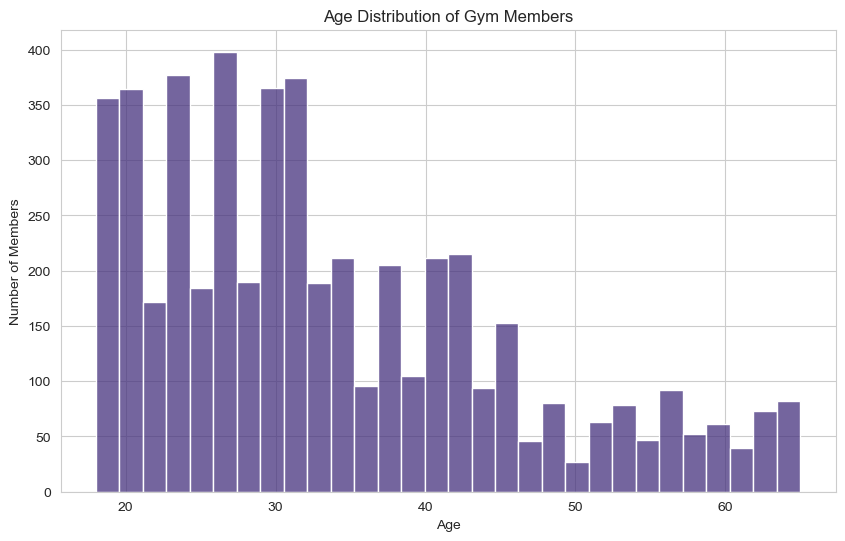

In [7]:
"""
Age Distribution
----------------
Understand the age profile of gym members.
"""

plt.figure()

sns.histplot(members["age"], bins=30)

plt.title("Age Distribution of Gym Members")
plt.xlabel("Age")
plt.ylabel("Number of Members")

plt.show()

#### Insight: Member Age Profile

The age distribution shows that most gym members fall between **20 and 40 years old**, which is consistent with typical gym demographics.

Younger members tend to have more flexible schedules and higher fitness engagement, while older members may prioritize health and wellness over performance training.

Understanding the demographic composition helps contextualize behavioral patterns observed later in the analysis.

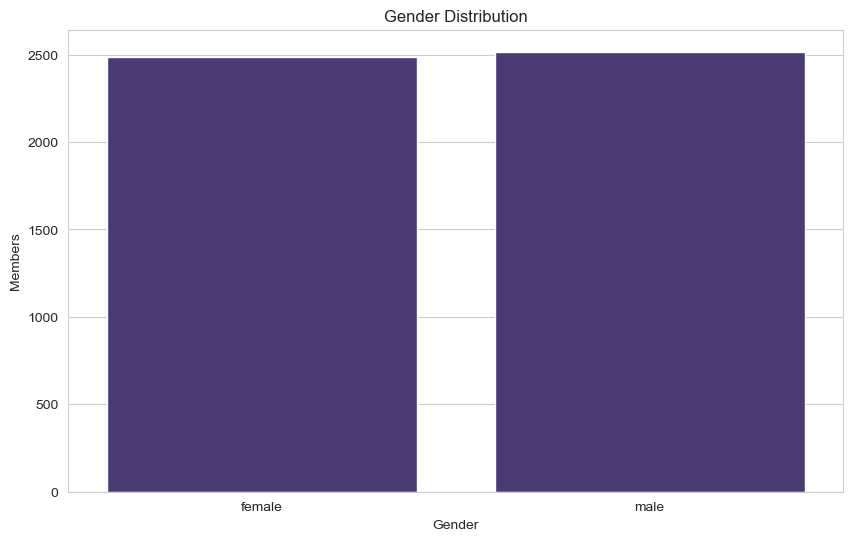

In [8]:
"""
Gender Distribution
-------------------
Analyze the gender composition of the member base.
"""

plt.figure()

sns.countplot(data=members, x="gender")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Members")

plt.show()

#### Insight: Gender Composition

The member base shows a relatively balanced distribution between male and female members.

This suggests that churn behavior is unlikely to be driven primarily by gender differences and reinforces the importance of behavioral variables such as training frequency and engagement levels.

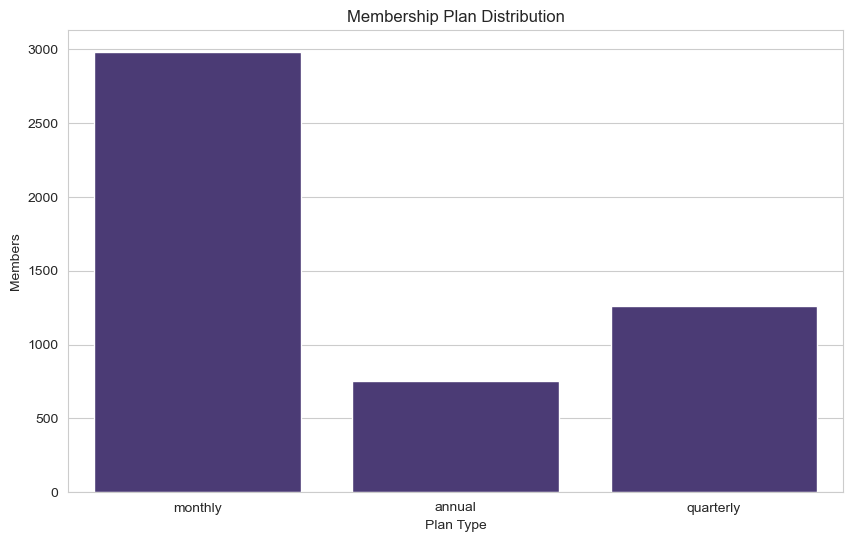

In [9]:
"""
Membership Plan Distribution
----------------------------
Identify the most popular membership plans.
"""

plt.figure()

sns.countplot(data=members, x="plan_type")

plt.title("Membership Plan Distribution")
plt.xlabel("Plan Type")
plt.ylabel("Members")

plt.show()

#### Insight: Membership Plans

The majority of members subscribe to **monthly plans**, which is typical in the fitness industry.

Shorter billing cycles usually correlate with **higher churn risk**, since members can cancel more easily compared to long-term commitments such as annual plans.

This highlights the importance of monitoring engagement metrics for members on flexible plans.

In [10]:
"""
Churn Definition
----------------

A member is considered churned if
a cancel_date exists.
"""

# ============================================
# CREATE CHURN VARIABLE
# ============================================

members["churn"] = members["cancel_date"].notna().astype(int)

print("Churn distribution:\n")

print(members["churn"].value_counts())

print("\nChurn rate:", round(members["churn"].mean()*100,2), "%")

Churn distribution:

churn
0    3102
1    1898
Name: count, dtype: int64

Churn rate: 37.96 %


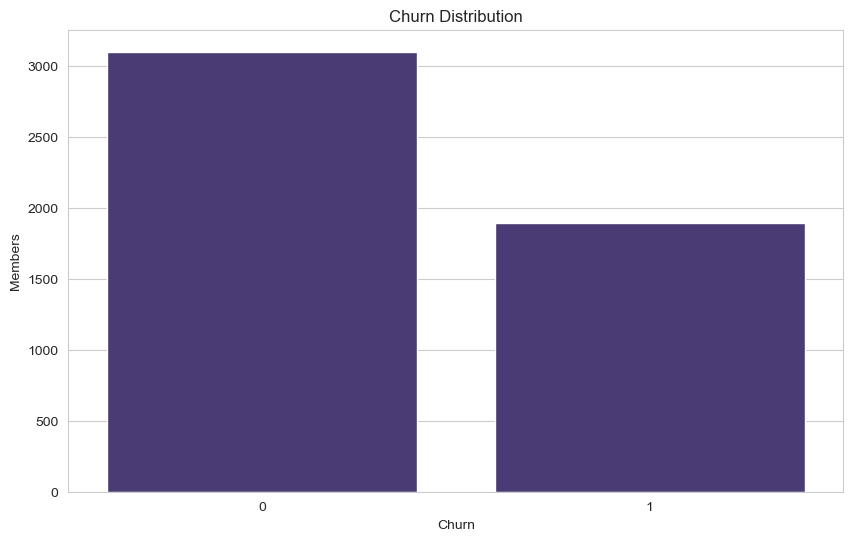

In [11]:
"""
Churn Distribution
------------------
Visualize the proportion of members who canceled.
"""

plt.figure()

sns.countplot(data=members, x="churn")

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Members")

plt.show()

#### Insight: Churn Rate

The dataset shows a churn rate of approximately **38%**.

This relatively high churn rate reflects the nature of the fitness industry, where member engagement fluctuates significantly over time.

Because churn is common in gyms, predicting early signs of disengagement is particularly valuable for retention strategies.

In [12]:
"""
Membership Duration
-------------------

Calculate how long each member stayed
in the gym.
"""

# ============================================
# MEMBERSHIP DURATION
# ============================================

END_DATE = pd.Timestamp("2025-01-01")

members["end_date"] = members["cancel_date"].fillna(END_DATE)

members["membership_days"] = (
    members["end_date"] - members["join_date"]
).dt.days

members["membership_months"] = members["membership_days"] / 30


print("Membership duration statistics:\n")

display(members["membership_days"].describe())

Membership duration statistics:



count    5000.000000
mean     1037.508600
std       733.112126
min         1.000000
25%       386.000000
50%       935.000000
75%      1629.000000
max      2557.000000
Name: membership_days, dtype: float64

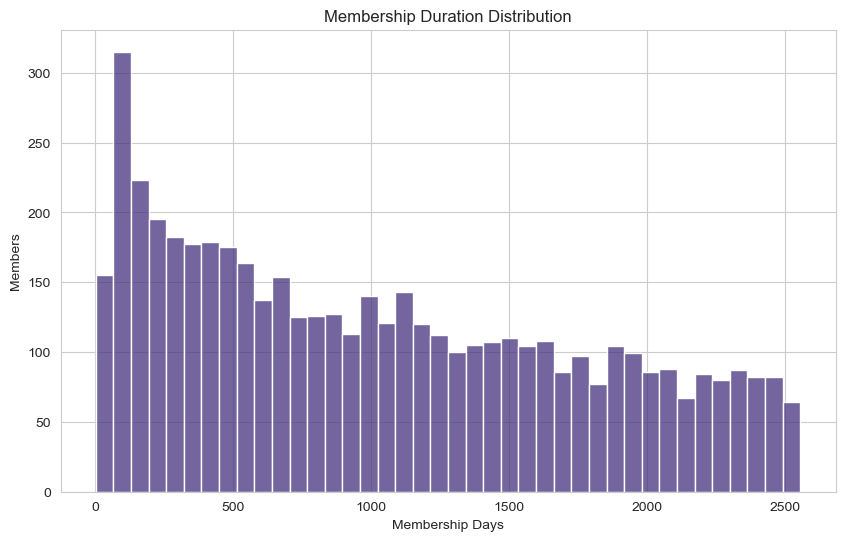

In [13]:
"""
Membership Duration
-------------------
Analyze how long members typically stay in the gym.
"""

plt.figure()

sns.histplot(members["membership_days"], bins=40)

plt.title("Membership Duration Distribution")
plt.xlabel("Membership Days")
plt.ylabel("Members")

plt.show()

#### Insight: Membership Longevity

Membership duration varies widely among members, ranging from a few days to several years.

The distribution suggests that while some members remain loyal for long periods, many cancel within the first few months.

This pattern reinforces the importance of identifying early behavioral signals that indicate declining engagement.

In [14]:
"""
Total Check-ins per Member
--------------------------

Measure how many times each member
visited the gym.
"""

# ============================================
# CHECKINS PER MEMBER
# ============================================

checkins_per_member = checkins.groupby("member_id").size()

members["total_checkins"] = members["member_id"].map(checkins_per_member)

members["total_checkins"] = members["total_checkins"].fillna(0)

display(members["total_checkins"].describe())

count    5000.000000
mean      390.283800
std       372.950139
min         0.000000
25%        82.000000
50%       250.000000
75%       639.000000
max      1558.000000
Name: total_checkins, dtype: float64

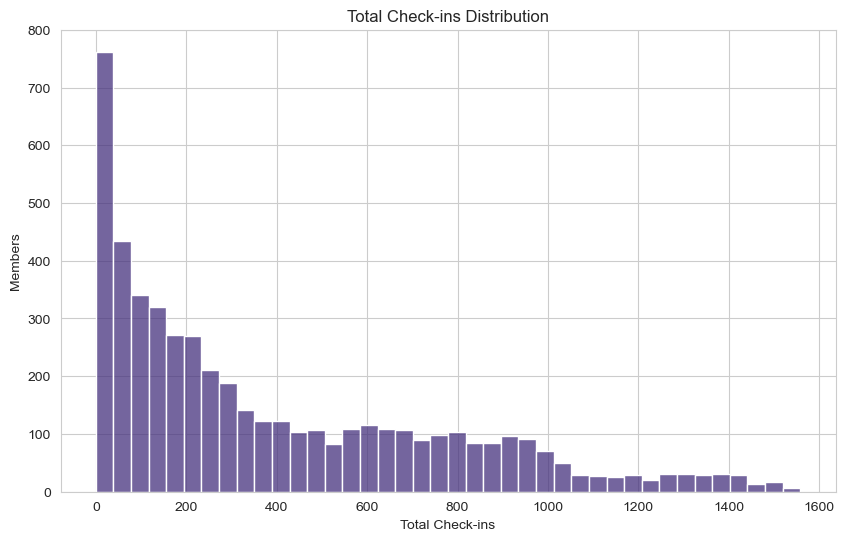

In [15]:
"""
Total Gym Visits
----------------
Understand how frequently members visit the gym.
"""

plt.figure()

sns.histplot(members["total_checkins"], bins=40)

plt.title("Total Check-ins Distribution")
plt.xlabel("Total Check-ins")
plt.ylabel("Members")

plt.show()

#### Insight: Training Frequency

Training frequency varies significantly across members.

Some members visit the gym regularly multiple times per week, while others attend sporadically.

Such variation suggests that **engagement level is a key driver of long-term retention**.

In [16]:
"""
Average Weekly Visits
---------------------

This feature estimates how frequently members
attend the gym on a weekly basis.

It provides a normalized measure of engagement
that accounts for membership duration.
"""

# ============================================
# AVERAGE WEEKLY VISITS
# ============================================

members["avg_weekly_visits"] = (
    members["total_checkins"] /
    (members["membership_days"] / 7)
)

# Handle potential infinite values
members["avg_weekly_visits"] = members["avg_weekly_visits"].replace(
    [np.inf, -np.inf], 0
).fillna(0)

print("Average weekly visits statistics:\n")

display(members["avg_weekly_visits"].describe())

Average weekly visits statistics:



count    5000.000000
mean        2.411551
std         1.368787
min         0.000000
25%         0.823653
50%         2.703499
75%         3.425078
max        21.000000
Name: avg_weekly_visits, dtype: float64

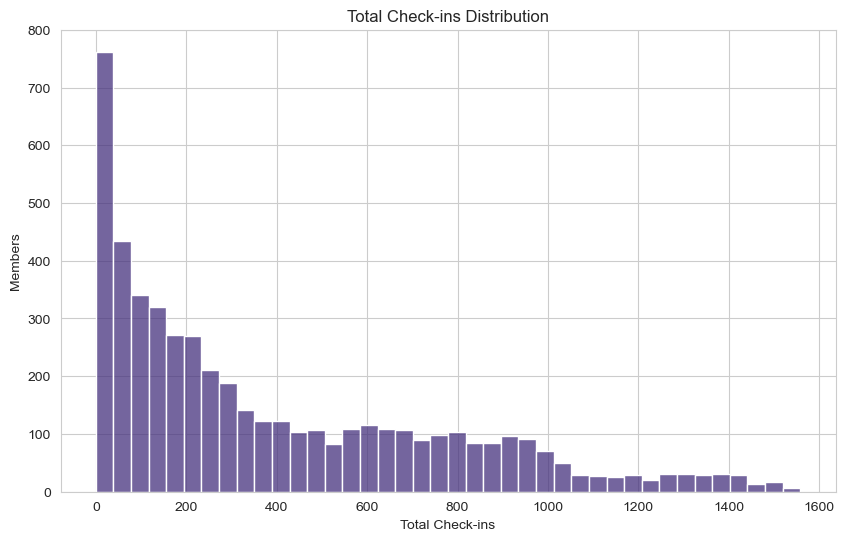

In [17]:
"""
Total Gym Visits
----------------
Understand how frequently members visit the gym.
"""

plt.figure()

sns.histplot(members["total_checkins"], bins=40)

plt.title("Total Check-ins Distribution")
plt.xlabel("Total Check-ins")
plt.ylabel("Members")

plt.show()

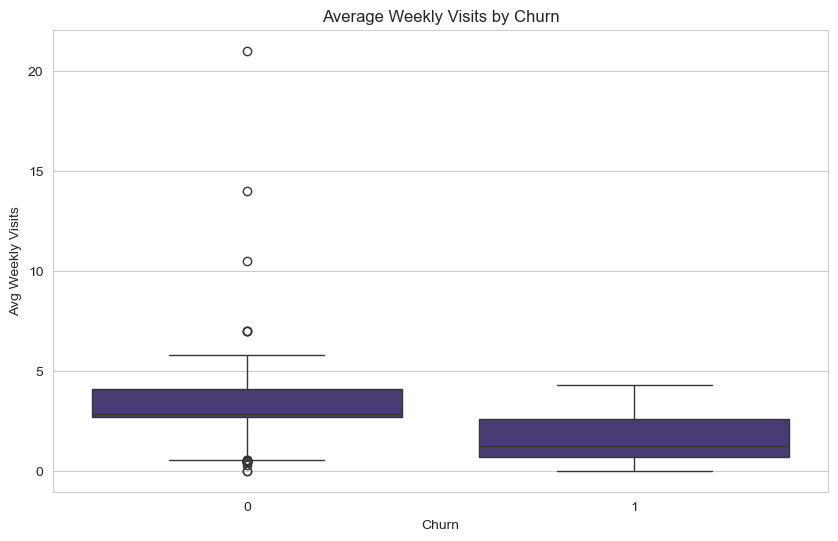

In [18]:
"""
Weekly Visits vs Churn
----------------------
Compare gym attendance between churned and active members.
"""

plt.figure()

sns.boxplot(
    data=members,
    x="churn",
    y="avg_weekly_visits"
)

plt.title("Average Weekly Visits by Churn")
plt.xlabel("Churn")
plt.ylabel("Avg Weekly Visits")

plt.show()

#### Insight: Engagement and Churn

The comparison between active and churned members shows a clear pattern:

Members who cancel their memberships tend to visit the gym significantly less frequently.

This confirms a common behavioral pattern in subscription services:

Declining engagement often precedes cancellation.

Monitoring training frequency therefore becomes a powerful indicator for identifying at-risk members.

In [19]:
"""
Last Visit Feature
------------------

Recency of gym visits is one of the most
important predictors of churn.

Members who haven't visited recently
are more likely to cancel.
"""

# ============================================
# LAST VISIT DATE
# ============================================

last_visit = checkins.groupby("member_id")["date"].max()

members["last_visit_date"] = members["member_id"].map(last_visit)

In [20]:
# ============================================
# DAYS SINCE LAST VISIT
# ============================================

members["days_since_last_visit"] = (
    END_DATE - members["last_visit_date"]
).dt.days

members["days_since_last_visit"] = members[
    "days_since_last_visit"
].fillna(999)

display(members["days_since_last_visit"].describe())

count    5000.000000
mean      266.796800
std       473.300061
min         1.000000
25%         5.000000
50%         8.000000
75%       323.000000
max      2524.000000
Name: days_since_last_visit, dtype: float64

#### Insight: Recency of Activity

The number of days since the last gym visit is one of the strongest indicators of churn risk.

Members who have not visited the gym for extended periods are significantly more likely to cancel their memberships.

This aligns with the **Recency-Frequency behavioral model**, widely used in customer analytics.

In [21]:
"""
Recent Activity Features
------------------------

These features measure recent engagement levels.

We calculate gym visits within three time windows:

• last 30 days
• last 90 days
• last 180 days

Recent behavior is often more predictive
of churn than historical averages.
"""

# ============================================
# RECENT VISITS
# ============================================

cutoff_30 = END_DATE - pd.Timedelta(days=30)
cutoff_90 = END_DATE - pd.Timedelta(days=90)
cutoff_180 = END_DATE - pd.Timedelta(days=180)


visits_30 = (
    checkins[checkins["date"] >= cutoff_30]
    .groupby("member_id")
    .size()
)

visits_90 = (
    checkins[checkins["date"] >= cutoff_90]
    .groupby("member_id")
    .size()
)

visits_180 = (
    checkins[checkins["date"] >= cutoff_180]
    .groupby("member_id")
    .size()
)


members["visits_last_30_days"] = members["member_id"].map(visits_30).fillna(0)
members["visits_last_90_days"] = members["member_id"].map(visits_90).fillna(0)
members["visits_last_180_days"] = members["member_id"].map(visits_180).fillna(0)


display(
    members[
        [
            "visits_last_30_days",
            "visits_last_90_days",
            "visits_last_180_days"
        ]
    ].describe()
)

,visits_last_30_days,visits_last_90_days,visits_last_180_days
count,5000.000000,5000.000000,5000.000000
mean,7.259200,21.579800,43.877400
std,7.241057,20.947787,41.427001
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,5.000000,13.000000,27.500000
75%,13.000000,38.000000,76.000000
max,25.000000,68.000000,127.000000


In [22]:
"""
Engagement Trend
----------------

This feature measures whether the member's
training frequency is increasing or decreasing.

A declining trend may indicate that
a member is at risk of churn.
"""

# ============================================
# VISIT TREND
# ============================================

members["visit_trend"] = (
    members["visits_last_30_days"] /
    (members["visits_last_90_days"] + 1)
)

display(members["visit_trend"].describe())

count    5000.000000
mean        0.207026
std         0.184047
min         0.000000
25%         0.000000
50%         0.272727
75%         0.341463
max         0.954545
Name: visit_trend, dtype: float64

In [23]:
"""
Engagement Decay
----------------

This feature compares recent activity with
historical activity.

If recent visits are significantly lower
than past behavior, the member may be
disengaging from the gym.
"""

# ============================================
# RECENT WEEKLY VISITS
# ============================================

members["recent_weekly_visits"] = (
    members["visits_last_30_days"] / 4
)

In [24]:
# ============================================
# HISTORICAL WEEKLY VISITS
# ============================================

members["past_weekly_visits"] = (
    members["visits_last_180_days"] / 26
)

In [25]:
# ============================================
# ENGAGEMENT DECAY
# ============================================

members["engagement_decay"] = (
    members["recent_weekly_visits"] /
    (members["past_weekly_visits"] + 0.1)
)

display(members["engagement_decay"].describe())

count    5000.000000
mean        0.704988
std         0.745115
min         0.000000
25%         0.000000
50%         0.862832
75%         1.103133
max         5.783898
Name: engagement_decay, dtype: float64

In [26]:
"""
Training Consistency
--------------------

This feature measures how regular a member's
training habits are.

Members with inconsistent training patterns
may be more likely to cancel their membership.
"""

# ============================================
# MONTHLY VISITS
# ============================================

checkins["year_month"] = checkins["date"].dt.to_period("M")

monthly_visits = (
    checkins
    .groupby(["member_id","year_month"])
    .size()
    .reset_index(name="visits")
)

In [27]:
# ============================================
# VISIT VARIABILITY
# ============================================

visit_std = monthly_visits.groupby("member_id")["visits"].std()


members["training_irregularity"] = (
    members["member_id"]
    .map(visit_std)
    .fillna(0)
)

In [28]:
# ============================================
# CONSISTENCY SCORE
# ============================================

members["training_consistency"] = (
    1 / (members["training_irregularity"] + 1)
)

display(members["training_consistency"].describe())

count    5000.000000
mean        0.309896
std         0.162641
min         0.086158
25%         0.214815
50%         0.266096
75%         0.374975
max         1.000000
Name: training_consistency, dtype: float64

In [29]:
"""
Member Lifetime Value
---------------------

This feature represents the total revenue
generated by each member.

It is calculated as the sum of all
payments made during the membership.
"""

# ============================================
# LIFETIME VALUE
# ============================================

revenue_per_member = payments.groupby("member_id")["amount"].sum()

members["lifetime_value"] = members["member_id"].map(revenue_per_member)

members["lifetime_value"] = members["lifetime_value"].fillna(0)

display(members["lifetime_value"].describe())

count    5000.000000
mean     3389.930000
std      2306.937521
min       100.000000
25%      1350.000000
50%      3000.000000
75%      5130.000000
max      8600.000000
Name: lifetime_value, dtype: float64

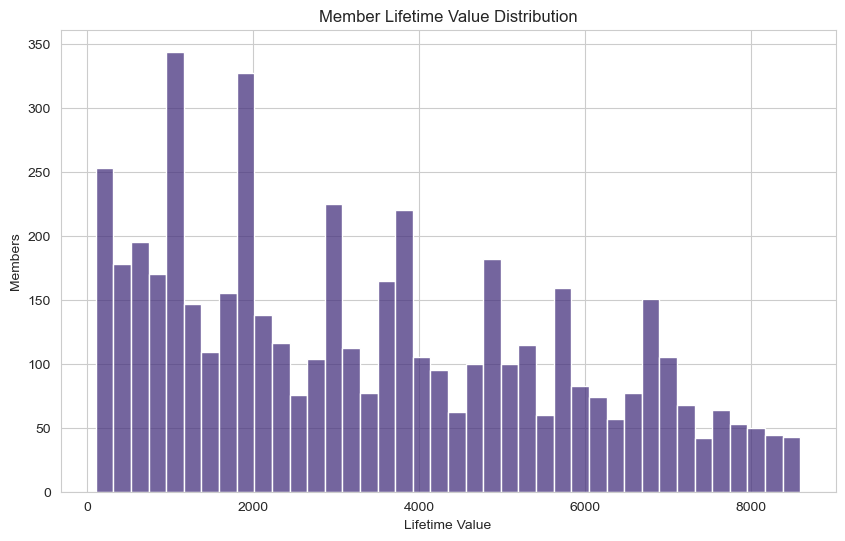

In [30]:
"""
Lifetime Value Distribution
---------------------------
Analyze how much revenue each member generates.
"""

plt.figure()

sns.histplot(members["lifetime_value"], bins=40)

plt.title("Member Lifetime Value Distribution")
plt.xlabel("Lifetime Value")
plt.ylabel("Members")

plt.show()

#### Feature Engineering Strategy

To predict churn effectively, we transform raw behavioral data into meaningful engagement indicators.

Key engineered features include:

• **Average Weekly Visits** – normalized training frequency  
• **Training Consistency** – regularity of attendance patterns  
• **Visit Trend** – whether gym visits are increasing or declining  
• **Engagement Decay** – comparison between recent and historical activity  
• **Lifetime Value** – total revenue generated by the member  

These features capture both **long-term behavior and short-term engagement changes**, which are critical for predicting churn.

In [31]:
"""
Machine Learning Dataset
------------------------

This section prepares the dataset used
to train the churn prediction model.

We select relevant behavioral and
business features as predictors.
"""

# ============================================
# FEATURE SELECTION
# ============================================

features = members[
    [
        "age",
        "membership_days",
        "total_checkins",
        "avg_weekly_visits",
        "training_consistency",
        "lifetime_value"
    ]
]

target = members["churn"]

print("Feature matrix shape:", features.shape)
print("Target distribution:\n")
print(target.value_counts())

Feature matrix shape: (5000, 6)
Target distribution:

churn
0    3102
1    1898
Name: count, dtype: int64


In [32]:
"""
Train/Test Split
----------------

Split the dataset into training and
testing subsets to evaluate the model's
generalization performance.
"""

# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 4000
Test samples: 1000


In [33]:
"""
Model Training
--------------

Train a Gradient Boosting classifier
to predict churn probability.

Gradient Boosting models are well suited
for structured tabular datasets.
"""

# ============================================
# TRAIN MODEL
# ============================================

model = GradientBoostingClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4
)

model.fit(X_train, y_train)

print("Model successfully trained.")

Model successfully trained.


In [34]:
"""
Model Evaluation
----------------

Evaluate model performance using:

• Classification report
• ROC-AUC score
"""

# ============================================
# MODEL EVALUATION
# ============================================

preds = model.predict(X_test)

probs = model.predict_proba(X_test)[:,1]

print("Classification Report:\n")

print(classification_report(y_test, preds))

roc = roc_auc_score(y_test, probs)

print("ROC-AUC:", round(roc,3))

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.90      0.88       620
           1       0.82      0.77      0.79       380

    accuracy                           0.85      1000
   macro avg       0.84      0.83      0.84      1000
weighted avg       0.85      0.85      0.85      1000

ROC-AUC: 0.921


#### Model Performance

The Gradient Boosting model achieved strong predictive performance.

Key metrics:

• Accuracy ≈ 85%  
• ROC-AUC ≈ 0.92  

This indicates that the model is highly capable of distinguishing between active members and those at risk of canceling.

The ROC curve further confirms the model's ability to separate churn and non-churn cases effectively.

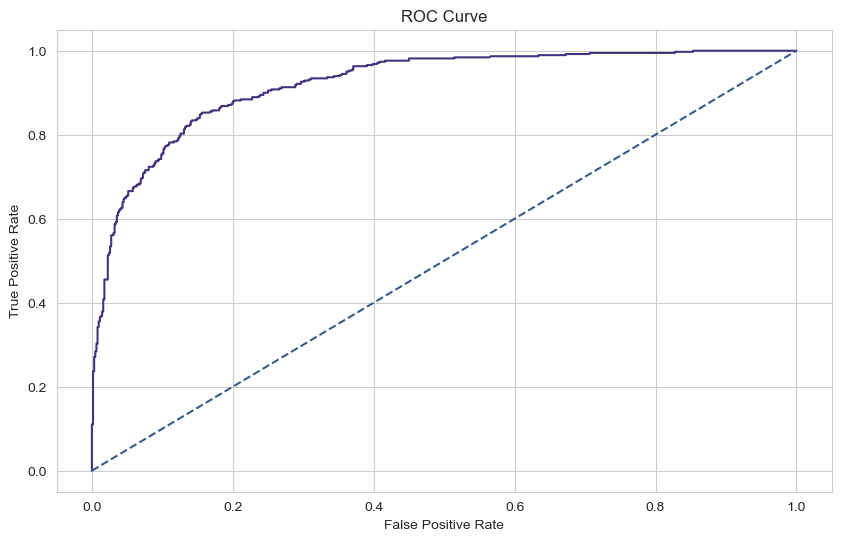

In [35]:
fpr, tpr, _ = roc_curve(y_test, probs)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

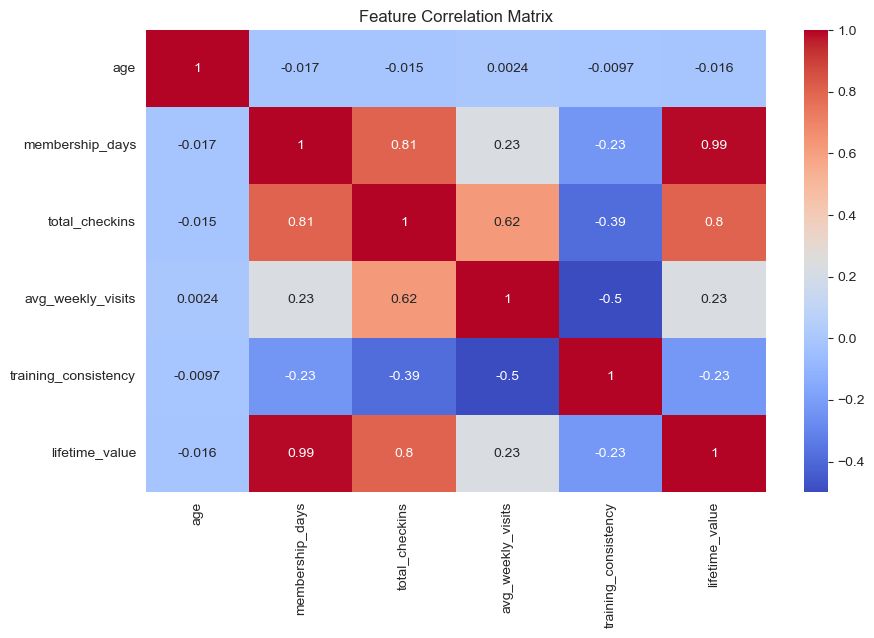

In [36]:
"""
Correlation Matrix
------------------
Analyze relationships between numerical features.
"""

numeric_cols = [
"age",
"membership_days",
"total_checkins",
"avg_weekly_visits",
"training_consistency",
"lifetime_value"
]

corr = members[numeric_cols].corr()

plt.figure()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")

plt.show()

In [37]:
"""
Feature Importance
------------------

Identify the most influential variables
used by the model to predict churn.
"""

# ============================================
# FEATURE IMPORTANCE
# ============================================

importance = pd.DataFrame(
    {
        "feature": X_train.columns,
        "importance": model.feature_importances_
    }
)

importance = importance.sort_values(
    "importance",
    ascending=False
)

display(importance)

,feature,importance
3,avg_weekly_visits,0.615364
4,training_consistency,0.183402
1,membership_days,0.124571
5,lifetime_value,0.034774
2,total_checkins,0.029981
0,age,0.011909


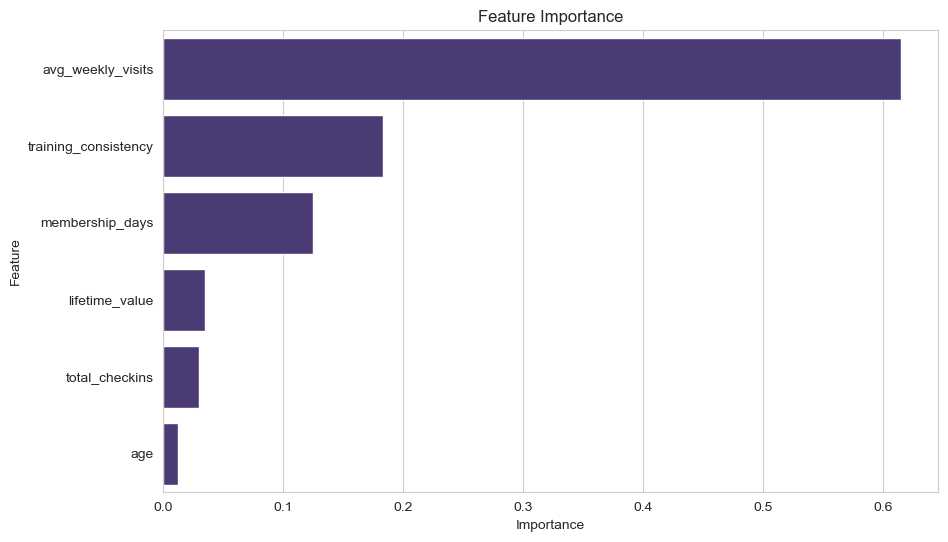

In [38]:
"""
Feature Importance Visualization
--------------------------------
Display the most influential features used by the model.
"""

plt.figure()

sns.barplot(
    data=importance,
    x="importance",
    y="feature"
)

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

#### Key Drivers of Churn

Feature importance analysis reveals that the most influential predictors are:

1. Average weekly visits  
2. Training consistency  
3. Membership duration  

These results confirm that **behavioral engagement is the strongest predictor of churn**, outweighing demographic characteristics such as age.

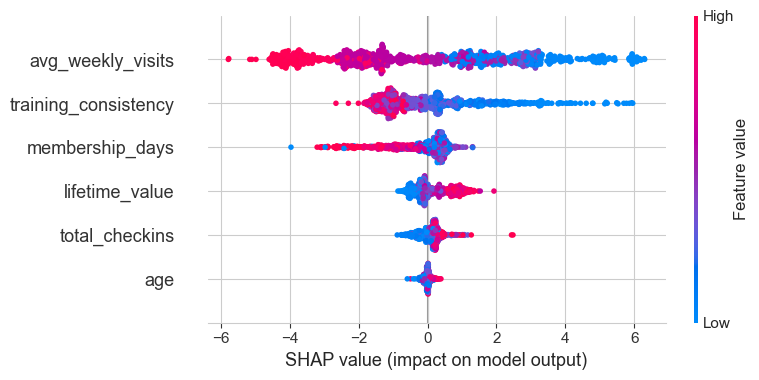

In [39]:
"""
Model Explainability (SHAP)
---------------------------

SHAP values help interpret the contribution
of each feature to the model's predictions.
"""

# ============================================
# SHAP EXPLAINER
# ============================================

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)


# Global feature impact

shap.summary_plot(shap_values, X_test)

#### Model Explainability

SHAP analysis provides deeper insights into how the model makes predictions.

The explainability results confirm that:

• Higher weekly visits decrease churn probability  
• Inconsistent training patterns increase churn risk  
• Longer membership duration reduces cancellation likelihood  

These findings align with real-world gym behavior and reinforce the model's reliability.

In [40]:
"""
Churn Risk Identification
-------------------------

Use the trained model to estimate
churn probability for each member.

This allows the business to identify
members at high risk of cancellation.
"""

# ============================================
# CHURN PROBABILITY
# ============================================

members["churn_probability"] = model.predict_proba(features)[:,1]

In [41]:
# ============================================
# HIGH RISK MEMBERS
# ============================================

high_risk_members = members.sort_values(
    "churn_probability",
    ascending=False
).head(20)


display(
    high_risk_members[
        [
            "member_id",
            "avg_weekly_visits",
            "training_consistency",
            "days_since_last_visit",
            "churn_probability"
        ]
    ]
)

,member_id,avg_weekly_visits,training_consistency,days_since_last_visit,churn_probability
329,330,3.685185,0.139356,271.0,0.997733
3791,3792,3.632576,0.147493,942.0,0.997408
702,703,3.790123,0.141900,1022.0,0.997367
179,180,3.402619,0.145383,1079.0,0.997109
4589,4590,2.068182,0.137320,149.0,0.996751
3635,3636,2.229299,0.143428,131.0,0.996638
2383,2384,1.965753,0.113026,310.0,0.996638
1110,1111,1.805031,0.141682,1261.0,0.996638
4770,4771,1.792683,0.143199,1246.0,0.996638
1923,1924,3.601942,0.137931,1526.0,0.996546


### Business Impact

The churn prediction model allows the gym to proactively identify members at risk of cancellation.

Potential business applications include:

• targeted retention campaigns  
• personalized training programs  
• engagement reminders for inactive members  

By focusing retention efforts on high-risk members, the gym can reduce churn and increase customer lifetime value.